# Customer Segmentation — Exploratory Data Analysis

This notebook explores the UCI Online Retail dataset: ~541 k transaction rows from a UK-based online gift retailer covering December 2010 – December 2011. The goal is to understand the raw data before we transform it into an RFM (Recency, Frequency, Monetary) table for clustering.

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/online_retail.csv', encoding='utf-8')
print('Shape:', df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Dataset Overview

Each row is one line item on a customer invoice. Key columns are `InvoiceNo`, `CustomerID`, `Quantity`, `UnitPrice`, and `InvoiceDate`. We note that `CustomerID` is missing for ~25 % of rows — those rows will be dropped during cleaning because we cannot attribute them to a specific customer.

In [3]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)

Shape: (541909, 8)

Dtypes:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,2011-10-31 14:41:00,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
print('Missing values:')
print(pd.concat([missing, pct_missing], axis=1,
                keys=['Count', '%']).loc[missing > 0])
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values:
              Count      %
Description    1454   0.27
CustomerID   135080  24.93



Duplicate rows: 5268


## 3. Transactions Over Time

We parse `InvoiceDate` and aggregate to monthly transaction counts and revenue. December 2010 and November 2011 are the busiest months, with a notable dip in February–March.

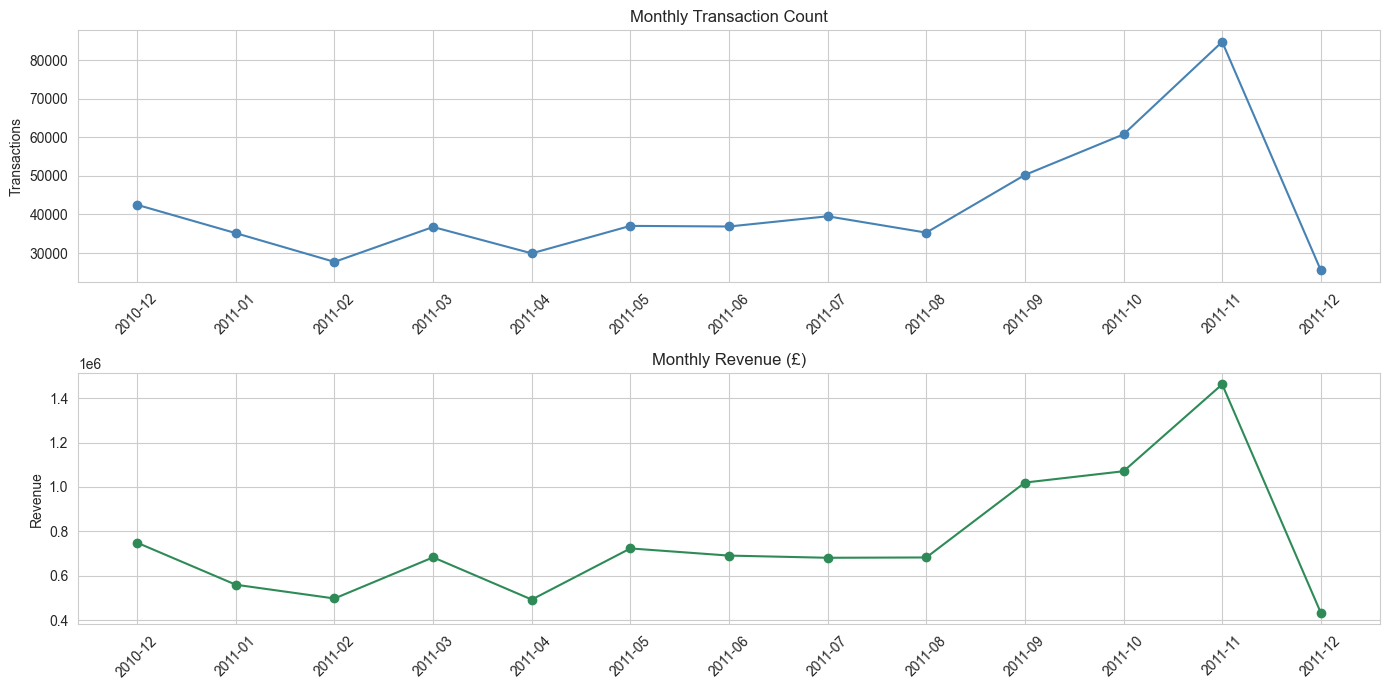

In [6]:
df_time = df.copy()
df_time['InvoiceDate'] = pd.to_datetime(df_time['InvoiceDate'])
df_time['YearMonth'] = df_time['InvoiceDate'].dt.to_period('M')
df_time['TotalPrice'] = df_time['Quantity'] * df_time['UnitPrice']

monthly = df_time.groupby('YearMonth').agg(
    Transactions=('InvoiceNo', 'count'),
    Revenue=('TotalPrice', 'sum')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(monthly['YearMonth'], monthly['Transactions'], marker='o', color='steelblue')
axes[0].set_title('Monthly Transaction Count'); axes[0].set_ylabel('Transactions')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['YearMonth'], monthly['Revenue'], marker='o', color='seagreen')
axes[1].set_title('Monthly Revenue (£)'); axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 4. Top 10 Countries — Transactions and Revenue

The overwhelming majority of transactions originate from the United Kingdom. The next largest markets are Germany, France, EIRE (Ireland), and the Netherlands.

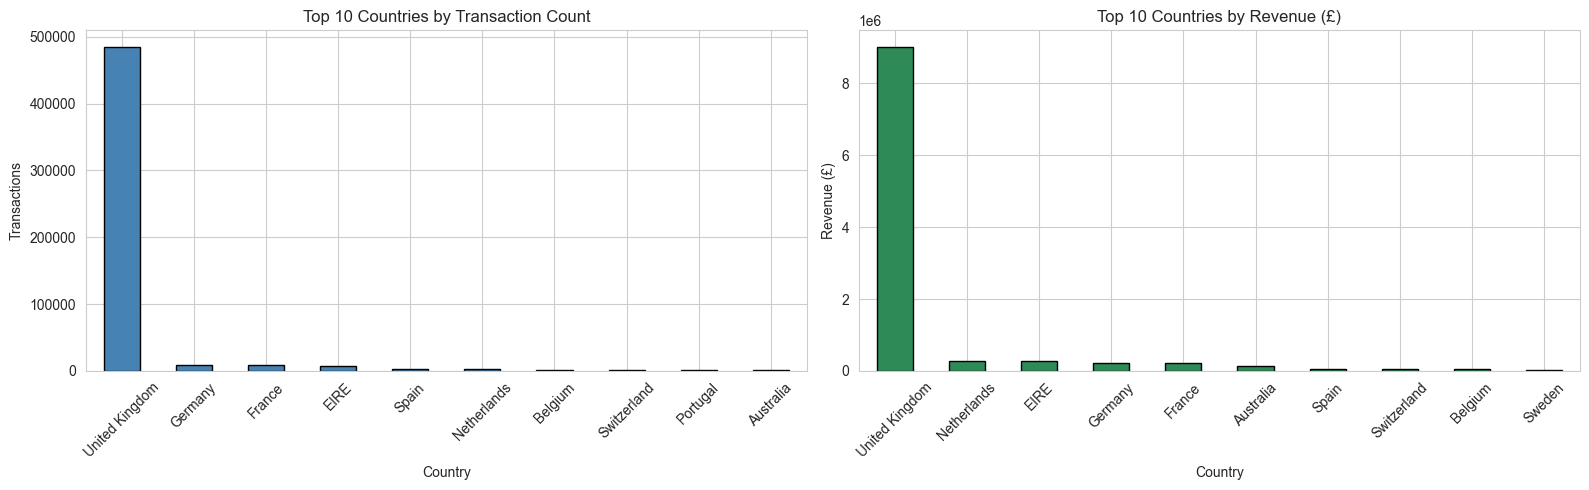

In [7]:
df_valid = df_time[(df_time['Quantity'] > 0) & (df_time['UnitPrice'] > 0)].copy()

top_txn = df_valid['Country'].value_counts().head(10)
top_rev = df_valid.groupby('Country')['TotalPrice'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_txn.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 Countries by Transaction Count')
axes[0].set_ylabel('Transactions'); axes[0].tick_params(axis='x', rotation=45)

top_rev.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Top 10 Countries by Revenue (£)')
axes[1].set_ylabel('Revenue (£)'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 5. Top Selling Products

Looking at the top products by quantity sold reveals a mix of decorative homeware and gift items — consistent with the retailer's positioning as a gift-ware supplier. "WORLD WAR 2 GLIDERS ASSTD DESIGNS" and "JUMBO BAG RED RETROSPOT" dominate by volume.

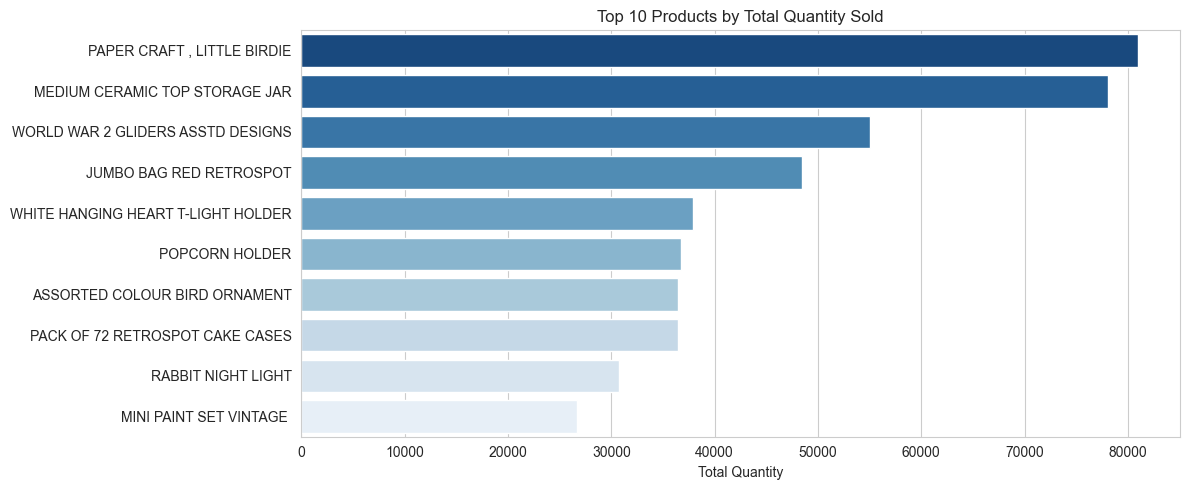

In [8]:
top_products = (df_valid.groupby('Description')['Quantity']
                .sum().nlargest(10).reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x='Quantity', y='Description', palette='Blues_r')
plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Total Quantity'); plt.ylabel('')
plt.tight_layout(); plt.show()

## 6. Distributions of Quantity and UnitPrice

Both columns are heavily right-skewed with long positive tails. Negative `Quantity` values (returns / cancellations) are visible in the raw data; these will be removed during cleaning. The log scale reveals the bulk of transactions cluster around small quantities and low unit prices.

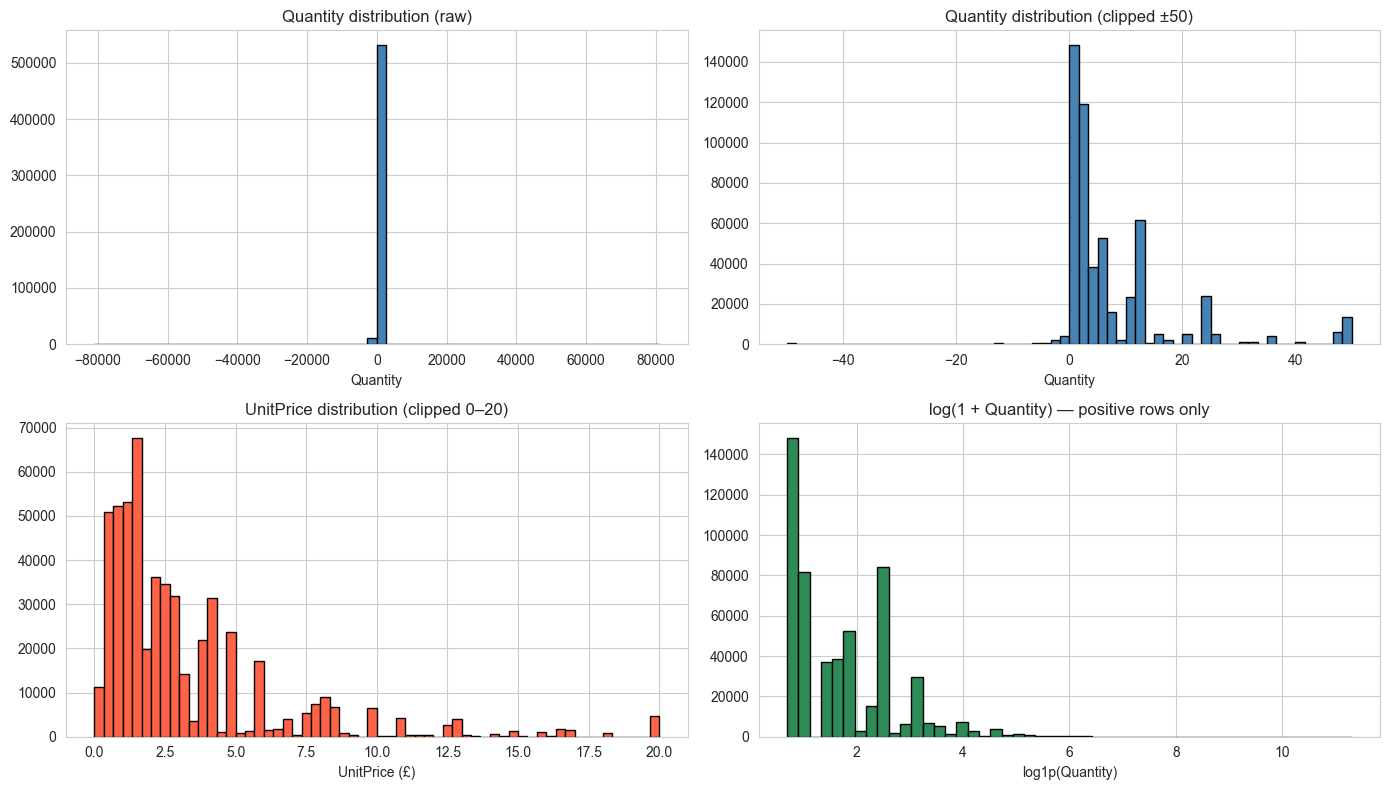

Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df['Quantity'], bins=60, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Quantity distribution (raw)')
axes[0, 0].set_xlabel('Quantity')

axes[0, 1].hist(df['Quantity'].clip(-50, 50), bins=60, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Quantity distribution (clipped ±50)')
axes[0, 1].set_xlabel('Quantity')

axes[1, 0].hist(df['UnitPrice'].clip(0, 20), bins=60, color='tomato', edgecolor='black')
axes[1, 0].set_title('UnitPrice distribution (clipped 0–20)')
axes[1, 0].set_xlabel('UnitPrice (£)')

pos_qty = df['Quantity'][df['Quantity'] > 0]
axes[1, 1].hist(np.log1p(pos_qty), bins=50, color='seagreen', edgecolor='black')
axes[1, 1].set_title('log(1 + Quantity) — positive rows only')
axes[1, 1].set_xlabel('log1p(Quantity)')

plt.tight_layout(); plt.show()

print('Rows with Quantity <= 0:', (df['Quantity'] <= 0).sum())
print('Rows with UnitPrice <= 0:', (df['UnitPrice'] <= 0).sum())

## 7. Preview of Customer-Level RFM Distributions

As a preview, we compute a quick RFM aggregation on the valid rows (positive Quantity, positive UnitPrice, non-null CustomerID). The distributions confirm heavy right-skew in all three metrics — log-transforming before clustering will be important.

In [10]:
df_rfm_preview = df_valid.dropna(subset=['CustomerID']).copy()
df_rfm_preview = df_rfm_preview[~df_rfm_preview['InvoiceNo'].astype(str).str.startswith('C')]
snapshot = df_rfm_preview['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_prev = df_rfm_preview.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print('Unique customers (after quick filter):', len(rfm_prev))
rfm_prev.describe().T

Unique customers (after quick filter): 4338


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250,15299.500,16778.75,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


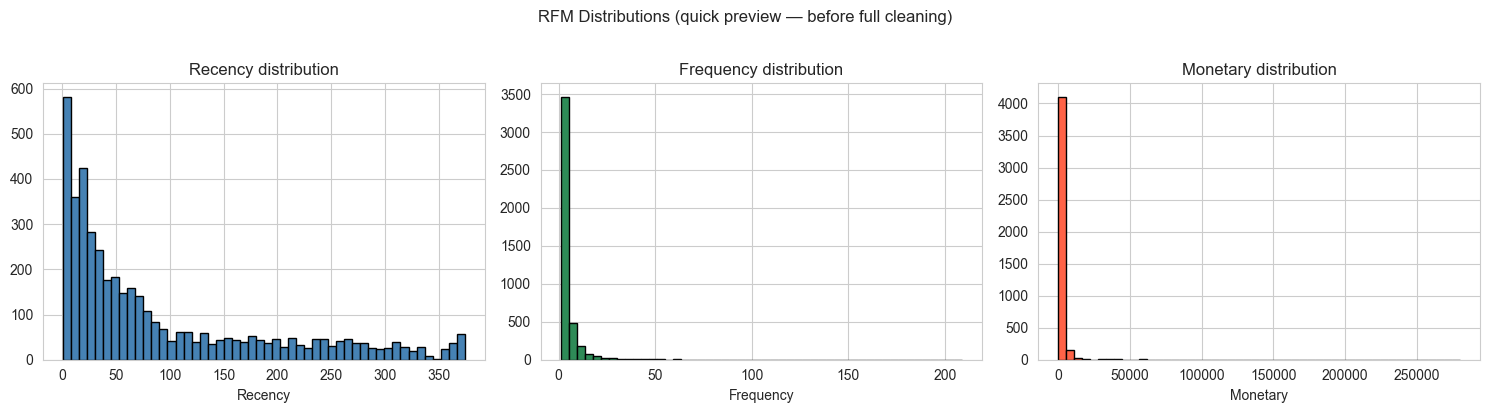

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
                           ['Recency', 'Frequency', 'Monetary'],
                           ['steelblue', 'seagreen', 'tomato']):
    ax.hist(rfm_prev[col], bins=50, color=color, edgecolor='black')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
plt.suptitle('RFM Distributions (quick preview — before full cleaning)', y=1.02)
plt.tight_layout(); plt.show()

## 8. Summary of Key Findings

| Finding | Detail |
|---|---|
| Total transaction rows | 541,909 |
| Missing CustomerID | ~135 k rows (~25%) — will be dropped |
| Cancellations (InvoiceNo starting 'C') | ~9.3 k rows — will be dropped |
| Non-positive Quantity / UnitPrice rows | small number — will be dropped |
| Unique customers (after filtering) | ~4,300 |
| Date range | Dec 2010 – Dec 2011 |
| Dominant market | United Kingdom (~91% of transactions) |
| Heavy skew in RFM | log-transform required before K-Means |

All three RFM metrics are right-skewed; log-transformation and standardisation in notebook 02 will ensure K-Means is not dominated by high-value outliers.

In [12]:
print('EDA complete.')

EDA complete.
